In [1]:
import numpy as np
import pandas as pd

# Job Salary Prediction Model

## Project Overview

This project aims to build a predictive model for job salaries based on various features such as job title, experience, education level, skills count, industry, company size, location, remote work options, and certifications. The goal is to understand the factors influencing salary and to accurately predict a job seeker's potential earnings.

## Dataset

The dataset used for this analysis is `job_salary_prediction_dataset.csv`. It contains comprehensive information about various job profiles and their corresponding salaries. Key features include:

*   `job_title`: The specific job role.
*   `experience_years`: Number of years of professional experience.
*   `education_level`: Highest education qualification (e.g., Bachelor, Master, PhD, High School, Diploma).
*   `skills_count`: Number of distinct skills possessed.
*   `industry`: The sector the job belongs to.
*   `company_size`: Size of the employing company (e.g., Small, Medium, Large, Enterprise).
*   `location`: Geographical location of the job.
*   `remote_work`: Indicates if the job offers remote or hybrid work options.
*   `certifications`: Number of professional certifications.
*   `salary`: The target variable, representing the annual salary.

## Methodology

The project follows a standard machine learning pipeline:

### 1. Data Loading and Initial Inspection

The dataset was loaded using Pandas. Initial checks were performed for duplicates, data shape, data types, and missing values.

*   **No missing values** were found.
*   **No duplicate rows** were found.

### 2. Exploratory Data Analysis (EDA)

*   **Numerical Feature Analysis**: A correlation matrix was used to visualize the relationship between numerical features (`experience_years`, `skills_count`, `certifications`) and the `salary`. `experience_years` showed the strongest positive correlation with salary.
*   **Categorical Feature Analysis**: Box plots were generated for each categorical feature (`job_title`, `education_level`, `industry`, `company_size`, `location`, `remote_work`) against `salary` to understand how different categories impact salary distribution.

### 3. Data Preprocessing

To prepare the data for the machine learning model:

*   **Feature and Target Split**: The dataset was split into features (`X`) and the target variable (`y`, which is `salary`).
*   **Train-Test Split**: The data was divided into training (80%) and testing (20%) sets to evaluate the model's generalization performance.
*   **ColumnTransformer**: A `ColumnTransformer` was used to apply different preprocessing steps to numerical and categorical features:
    *   **Numerical Features**: Scaled using `StandardScaler` to normalize their range.
    *   **Categorical Features**: Encoded using `OneHotEncoder` to convert them into a numerical format suitable for the model.

### 4. Model Training

A `LinearRegression` model was chosen for its interpretability and effectiveness for regression tasks. A `Pipeline` was constructed to combine the preprocessing steps and the regression model.

*   The model was trained on the preprocessed training data (`X_train`, `y_train`).

### 5. Model Evaluation

The trained model's performance was evaluated on the unseen test set (`X_test`, `y_test`) using several regression metrics:

*   **Mean Absolute Error (MAE)**: Measures the average magnitude of the errors. `5436.10`
*   **Mean Squared Error (MSE)**: Penalizes larger errors more heavily. `50773076.89`
*   **Root Mean Squared Error (RMSE)**: The square root of MSE, in the same units as the target variable. `7125.52`
*   **R-squared (R2)**: Represents the proportion of variance in the dependent variable predictable from the independent variables. `0.96`

### 6. Visualization of Predicted vs. Actual Values

A scatter plot comparing `y_test` (actual salaries) against `y_pred` (predicted salaries) was generated. A diagonal red dashed line represents perfect prediction. The closer the predicted values are to this line, the better the model's performance.

## Results

The Linear Regression model achieved an **R-squared value of 0.96**, indicating that it explains approximately 96% of the variance in job salaries. The MAE and RMSE values suggest that the model's predictions are, on average, within a reasonable range of the actual salaries, demonstrating strong predictive capability.

## Usage

To run this project, clone the repository and open the Jupyter Notebook (or Google Colab notebook). Ensure you have all the necessary libraries installed (Pandas, NumPy, Scikit-learn, Matplotlib, Seaborn).

```bash
pip install pandas numpy scikit-learn matplotlib seaborn
```

Execute the cells sequentially to reproduce the analysis and model training.

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
df = pd.read_csv('/content/drive/MyDrive/job_salary_prediction_dataset.csv')
df.head(10)

,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary
0,AI Engineer,10,Bachelor,2,Healthcare,Medium,India,Hybrid,2,109413
1,Data Analyst,5,Bachelor,17,Telecom,Small,Australia,No,0,93764
2,Frontend Developer,18,PhD,4,Media,Medium,Singapore,No,1,148123
3,Business Analyst,19,PhD,13,Retail,Medium,Canada,Yes,0,189123
4,Product Manager,15,Bachelor,7,Manufacturing,Large,Sweden,Yes,0,165069
5,AI Engineer,0,High School,4,Education,Enterprise,USA,No,2,180351
6,Backend Developer,6,High School,16,Manufacturing,Enterprise,Canada,No,3,165375
7,Machine Learning Engineer,4,Bachelor,18,Healthcare,Enterprise,Canada,Hybrid,5,202463
8,AI Engineer,5,Diploma,14,Telecom,Enterprise,Singapore,Yes,0,171834
9,Frontend Developer,18,PhD,2,Retail,Enterprise,India,Hybrid,5,128377


In [4]:
df.duplicated().sum()

np.int64(0)

In [5]:
df.shape

(250000, 10)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   job_title         250000 non-null  object
 1   experience_years  250000 non-null  int64 
 2   education_level   250000 non-null  object
 3   skills_count      250000 non-null  int64 
 4   industry          250000 non-null  object
 5   company_size      250000 non-null  object
 6   location          250000 non-null  object
 7   remote_work       250000 non-null  object
 8   certifications    250000 non-null  int64 
 9   salary            250000 non-null  int64 
dtypes: int64(4), object(6)
memory usage: 19.1+ MB


In [7]:
df.describe()

,experience_years,skills_count,certifications,salary
count,250000.000000,250000.000000,250000.000000,250000.000000
mean,10.005408,9.997812,2.491928,145718.080524
std,6.060602,5.479288,1.706475,37407.952729
min,0.000000,1.000000,0.000000,31867.000000
25%,5.000000,5.000000,1.000000,119358.000000
50%,10.000000,10.000000,2.000000,143453.000000
75%,15.000000,15.000000,4.000000,169492.000000
max,20.000000,19.000000,5.000000,333046.000000


In [8]:
df.isnull().sum()

,0
job_title,0
experience_years,0
education_level,0
skills_count,0
industry,0
company_size,0
location,0
remote_work,0
certifications,0
salary,0


In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Identify numerical and categorical features
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

# Remove 'salary' from numerical_cols as it's the target variable
if 'salary' in numerical_cols:
    numerical_cols.remove('salary')

print(f"Numerical features: {numerical_cols}")
print(f"Categorical features: {categorical_cols}")

Numerical features: ['experience_years', 'skills_count', 'certifications']
Categorical features: ['job_title', 'education_level', 'industry', 'company_size', 'location', 'remote_work']


### 1. Analyzing Numerical Features (Correlation with Salary)

I use a heatmap to visualize the correlation matrix between the numerical features and the target variable, 'salary'. Correlation measures how two variables move in relation to each other. A higher absolute correlation value indicates a stronger relationship.

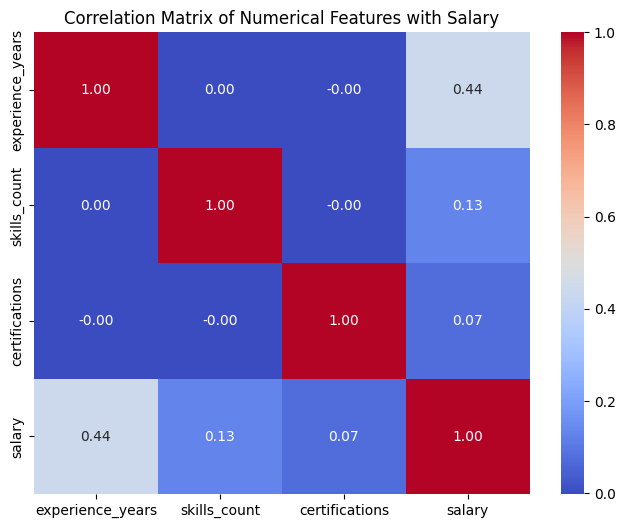

In [10]:
# Calculate the correlation matrix for numerical features including salary
correlation_matrix = df[numerical_cols + ['salary']].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Numerical Features with Salary')
plt.show()

### 2. Analyzing Categorical Features (Impact on Salary)

For categorical features, we can use box plots to visualize how the distribution of 'salary' varies across different categories of each feature. This helps us understand if a categorical feature has a significant impact on salary.

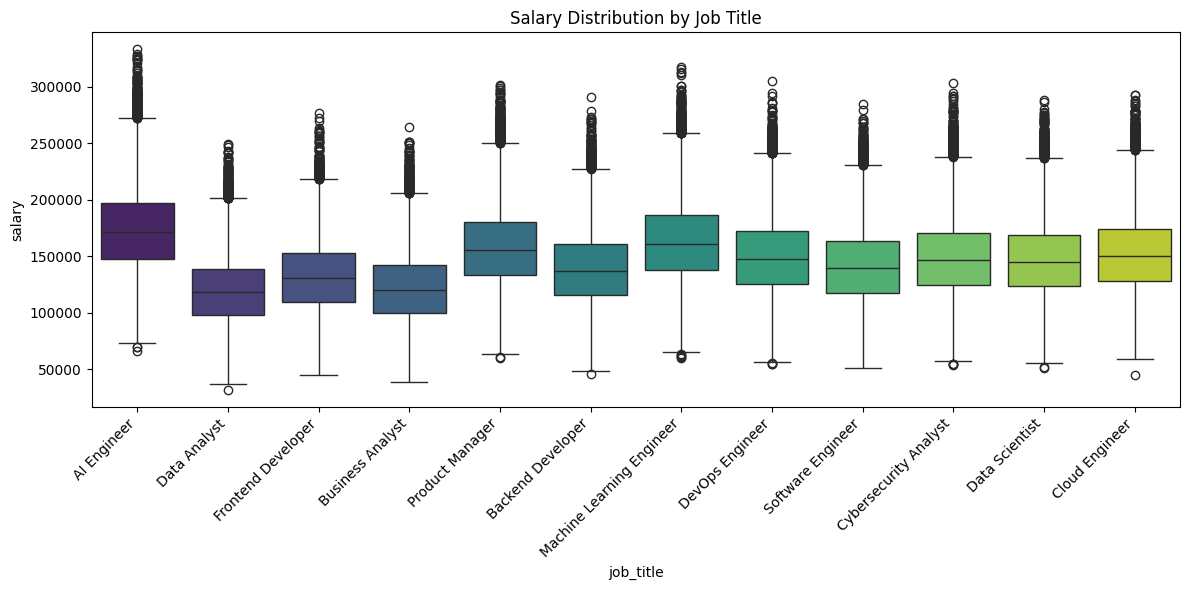

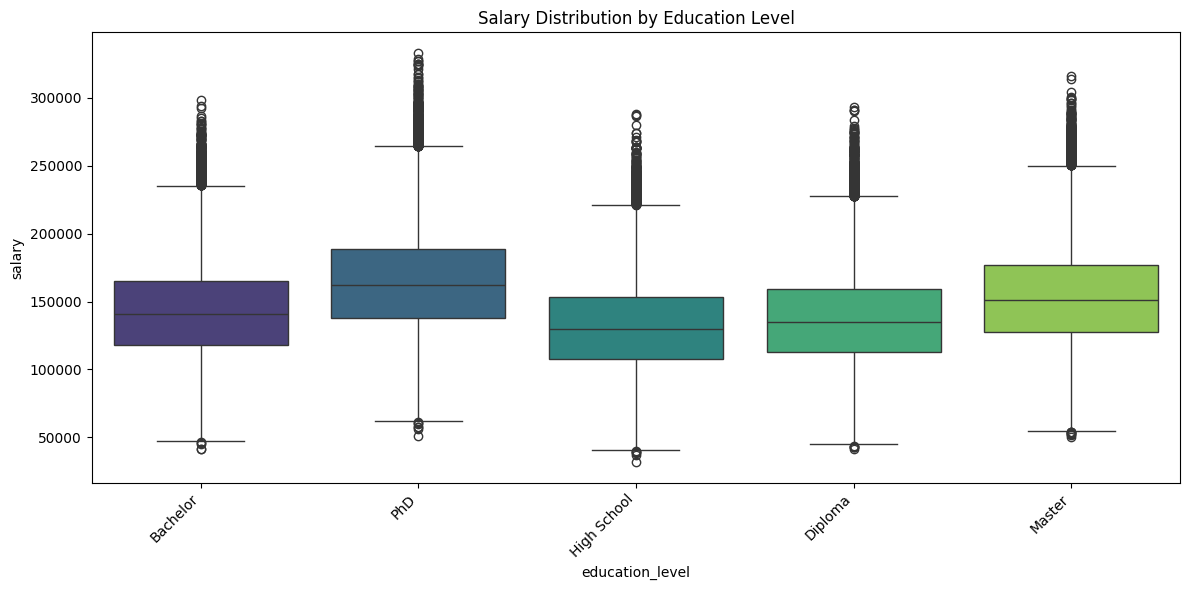

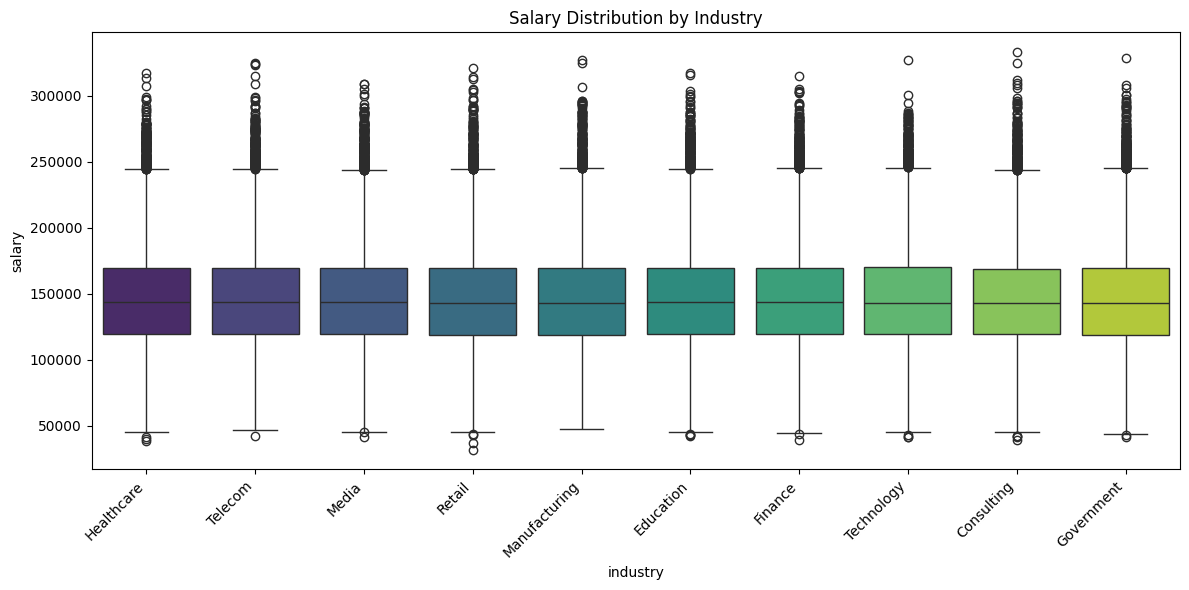

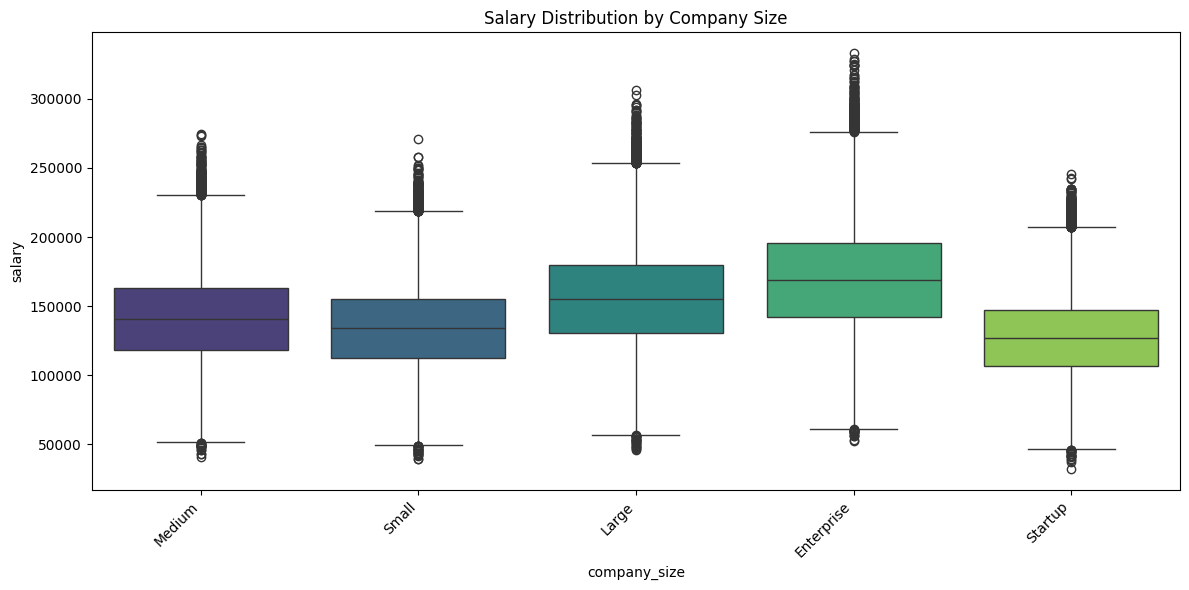

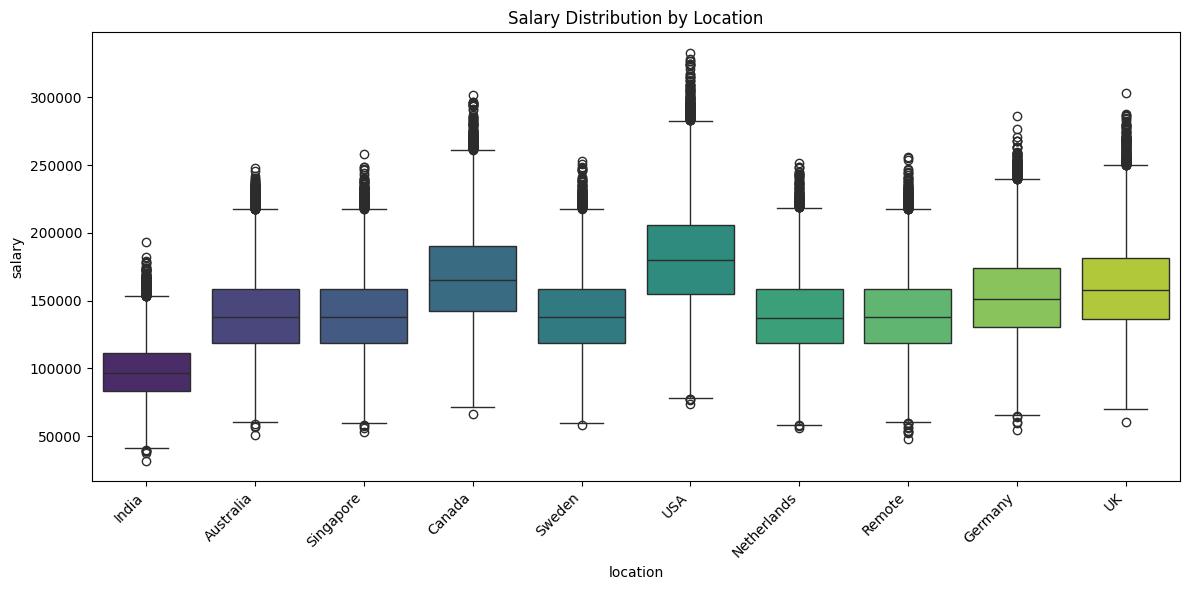

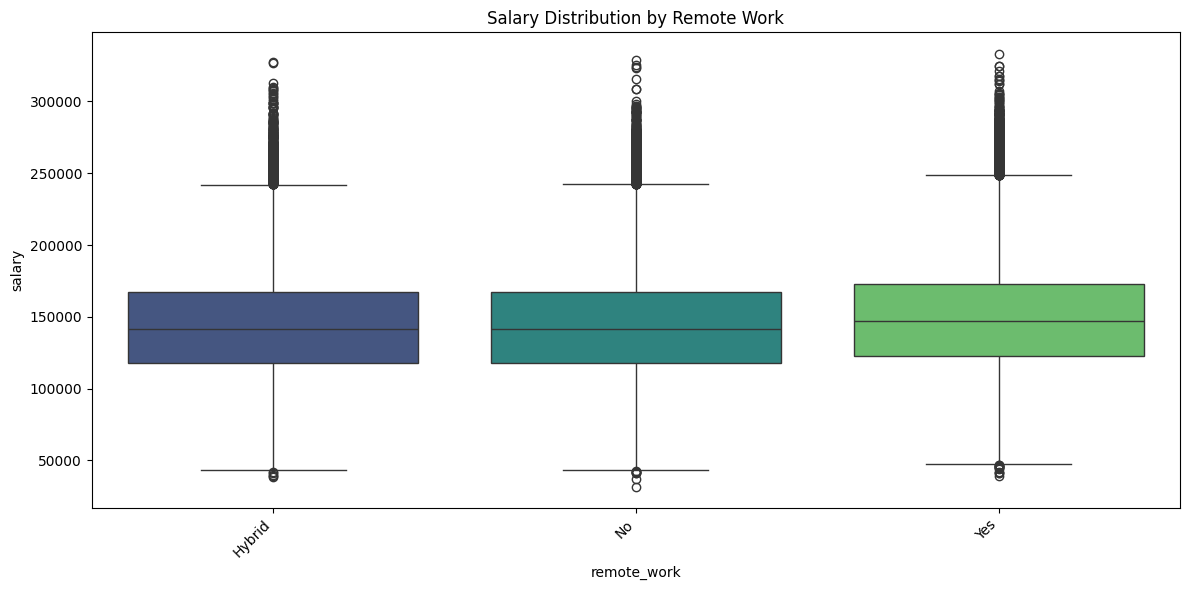

In [11]:
for col in categorical_cols:
    plt.figure(figsize=(12, 6))
    sns.boxplot(x=col, y='salary', data=df, palette='viridis', hue=col, legend=False)
    plt.title(f'Salary Distribution by {col.replace("_", " ").title()}')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

In [13]:
# Define features (X) and target (y)
X = df.drop('salary', axis=1)
y = df['salary']

# Identify numerical and categorical features for preprocessing
numerical_features = ['experience_years', 'skills_count', 'certifications']
categorical_features = ['job_title', 'education_level', 'industry', 'company_size', 'location', 'remote_work']

# Create preprocessing pipelines for numerical and categorical features
numerical_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Create a preprocessor using ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ])

print("Preprocessing pipelines created successfully.")

Preprocessing pipelines created successfully.


In [14]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")

Training set shape: (200000, 9)
Testing set shape: (50000, 9)


In [15]:
# Create the full pipeline with preprocessing and Linear Regression model
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

# Train the model
model.fit(X_train, y_train)

print("Linear Regression model trained successfully.")

Linear Regression model trained successfully.


### 4. Model Evaluation

Finally, we'll evaluate the trained model's performance on the test set using common regression metrics such as Mean Absolute Error (MAE), Mean Squared Error (MSE), and R-squared ($R^2$). These metrics will help us understand how well our model is predicting salaries.

In [16]:
# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared (R2): {r2:.2f}")

Mean Absolute Error (MAE): 5436.10
Mean Squared Error (MSE): 50773076.89
Root Mean Squared Error (RMSE): 7125.52
R-squared (R2): 0.96


### 5. Visualization of Predicted vs. Actual Values

To visually inspect the model's performance, we'll create a scatter plot comparing the `y_test` (actual salaries) against `y_pred` (predicted salaries). A perfect model would show all points lying on a 45-degree line, where predicted equals actual. We'll also add a regression line to see the general trend of our predictions.

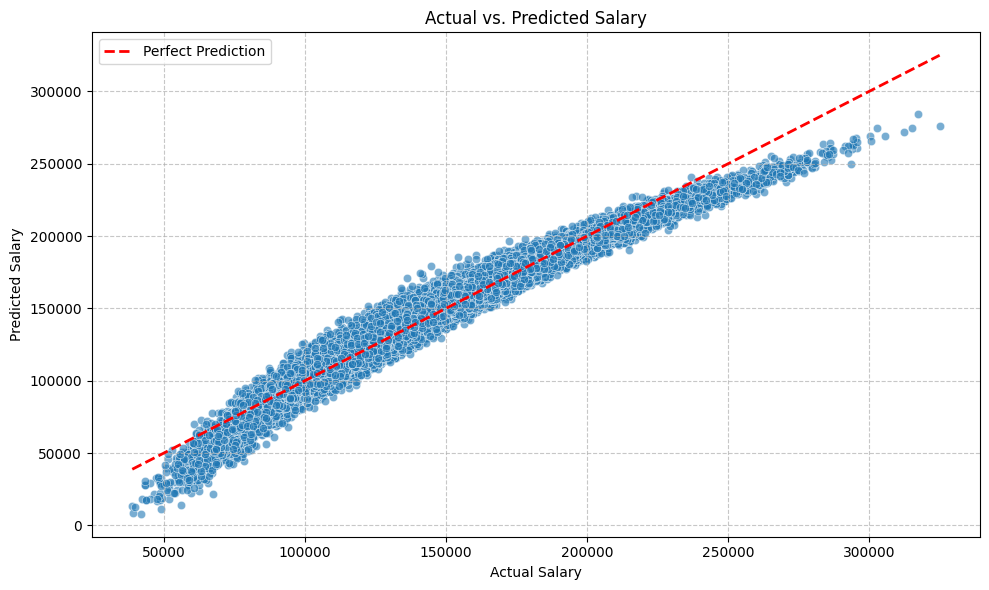

In [17]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual Salary')
plt.ylabel('Predicted Salary')
plt.title('Actual vs. Predicted Salary')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()